In [1]:
import os
print(os.getcwd())
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn import tree 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd


C:\Users\Sivaguru\ML lab


In [4]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["species"] = [iris.target_names[i] for i in iris.target]

iris_df.to_csv("iris.csv", index=False)

print("iris.csv created successfully!")

iris.csv created successfully!


In [5]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'exp1.ipynb', 'iris.csv']


In [6]:
iris_df = pd.read_csv("iris.csv")
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
iris_df.isnull().any() 

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
species              False
dtype: bool

In [8]:
iris_df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

In [9]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


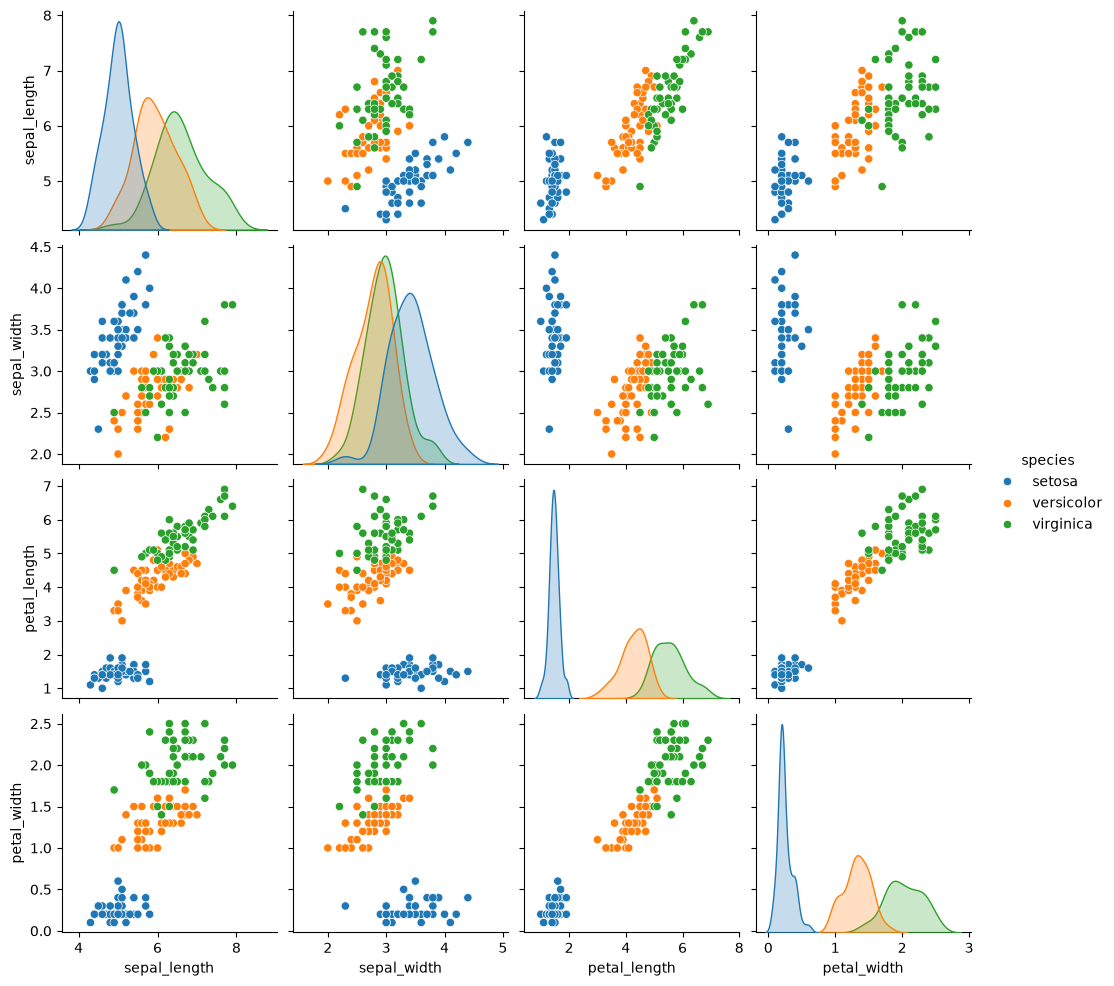

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
# Load the iris dataset 
iris_df = sns.load_dataset('iris')
# Pair plot - using 'species' instead of 'Species' 
sns.pairplot(iris_df, hue='species')
# Save the figure
plt.savefig("exercise2a.png")
# Display the figure
plt.show()

In [30]:
from sklearn.preprocessing import LabelEncoder
X = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = iris_df['species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=1)


In [31]:
clf = tree.DecisionTreeClassifier() 
clf = clf.fit(X_train, y_train)


In [32]:
prediction = clf.predict(X_test)

In [33]:
print(classification_report(y_test, prediction)) 

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         6
   virginica       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



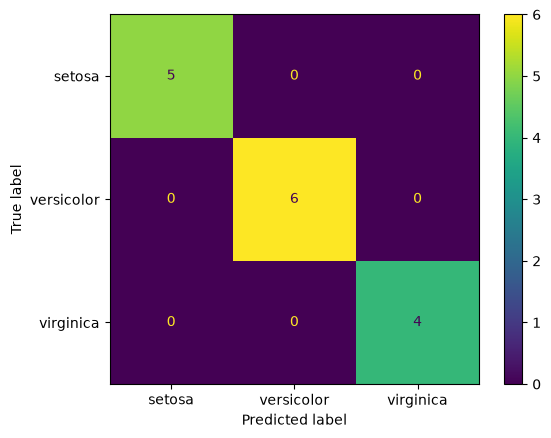

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Create and display confusion matrix directly from classifier
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.savefig("exercise2b.png") 
plt.show() 



In [2]:
!pip install pydotplus
!pip install graphviz


In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus



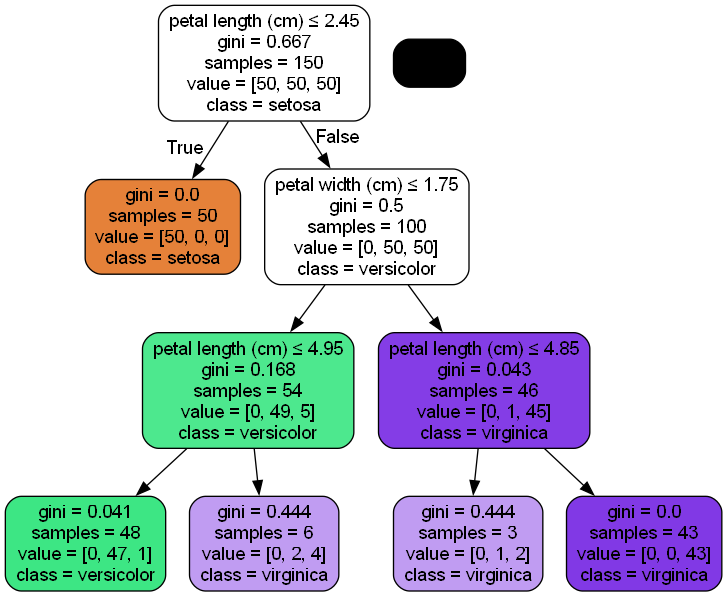

In [6]:
# 1. Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Train Decision Tree model
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# 3. Export tree to DOT format
dot_data = StringIO()

export_graphviz(
    clf,
    out_file=dot_data,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

# 4. Create graph
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

# 5. Save image
graph.write_png("decision_tree.png")

# 6. Display image in Jupyter Notebook
Image(graph.create_png())

In [7]:
SepalLengthCm = 4.8
SepalWidthCm = 2.9
PetalLengthCm = 1.3
PetalWidthCm = 0.2
x = [[SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]]
res = clf.predict(x)

# Simple class name mapping - only prints the predicted class
class_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
predicted_class = class_mapping[res[0]]
print("The class predicted is --> " + predicted_class)


The class predicted is --> setosa
